###### Carleton School of Information Technology
### ITEC 5920 – Applied Deep Learning
### Winter 2026
### Instructor: Dr. Marzieh Amini
### Prepared by: Aziz Al-Najjar


Sources: 




This tutorial provides an introduction to the basic concepts and usage of Multi-Layer Perceptron (MLP) using scikit-learn and Keras libraries in Python. MLP is a type of artificial neural network commonly used for classification and regression tasks. The tutorial covers the following topics:
regression

* How to train, evaluate, and visualize Multi-Layer Perceptron using the scikit-learn library.
* An overview of the Keras library and how to use it to build MLP models.
* How to train, evaluate, and visualize Multi-Layer Perceptron using the Keras library.
* Hyperparameter tuning using GridSearchCV in scikit-learn.

The tutorial includes code examples and visualizations to help you understand the concepts and usage of these algorithms. By the end of the tutorial, you will have a solid understanding of how to use Multi-Layer Perceptron in scikit-learn and Keras in your own projects and how to perform hyperparameter tuning to improve your models' performance.

## a. MLP using scikit-learn

### a.1. Loading the dataset

We will use the Digits dataset from scikit-learn's datasets module. This dataset contains handwritten digits images and their corresponding labels. The images are 8x8 pixels and there are 10 classes (0 to 9). To load the dataset, we will use the following code:

In [15]:
from sklearn import datasets

digits = datasets.load_digits()
X, y = digits.images, digits.target
print(X.shape)

(1797, 8, 8)


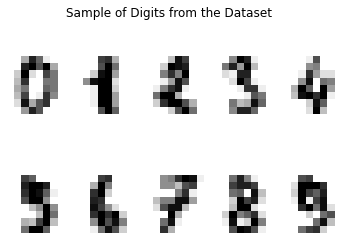

In [16]:
import matplotlib.pyplot as plt

# Plot first 15 digits in the dataset
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap='gray_r')
    plt.axis('off')
plt.suptitle("Sample of Digits from the Dataset")
plt.show()

#### a.1.1. Preprocessing the data

Since the images in the Digits dataset are 8x8 pixels, we need to reshape them into a 1-dimensional array to use them as input to our MLP. We will use the following code to do that:

In [17]:
X = X.reshape((X.shape[0], -1))

Additionally, it is common practice to scale the input data to have zero mean and unit variance. This can be achieved using the StandardScaler from scikit-learn's preprocessing module:

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

#### a.1.2. Splitting the data into training and testing sets:
Next, we need to split the data into training and testing sets. This will allow us to evaluate the performance of our MLP. We will use scikit-learn's train_test_split function for this:

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)
print(X_test.shape)


(1257, 64)
(540, 64)


### a.2. Training the MLP:
Next, we will create an MLP object using the MLPClassifier from scikit-learn's neural_network module.

Some of the important hyperparameters of MLPClassifier are:

* hidden_layer_sizes: This parameter sets the number and size of hidden layers in the network. The default value is (100,), which creates a single hidden layer with 100 neurons.
* activation: This parameter sets the activation function used in the hidden layers. The default value is ‘relu’, which stands for rectified linear unit.
* solver: This parameter sets the optimization algorithm used to train the model. The default value is ‘adam’, which is a popular optimization algorithm for deep learning.
* alpha: This parameter sets the L2 penalty (regularization term) parameter. The default value is 0.0001.
* batch_size: This parameter sets the size of the mini-batch used in mini-batch gradient descent. The default value is ‘auto’, which means the batch size is automatically determined based on the size of the data.

We will use the following code to create an MLP with 3 hidden layer of 50 neurons:

In [20]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50,50,50), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 50, 50), max_iter=1000, random_state=42)

### a.3. Evaluating the MLP:
To evaluate the performance of the MLP, we will use accuracy as our metric. We will use the following code to calculate the accuracy on the test set:


In [21]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(acc * 100))

Accuracy: 97.22%


We can also plot the confusion matrix to better visualize the perofmance of the model

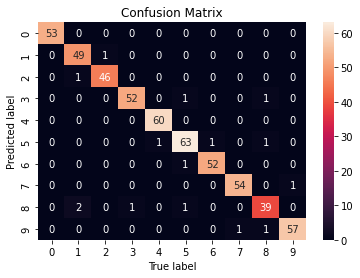

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()

##b. MLP using Keras

### b.1. Loading the MNIST Dataset:
We'll be using the MNIST dataset which is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images. The MNIST dataset is included in Keras and can be easily loaded using the following code:

In [30]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


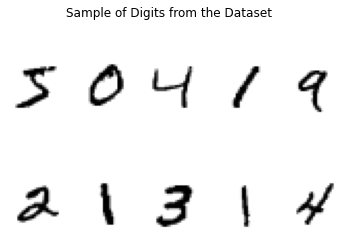

In [31]:
import matplotlib.pyplot as plt

# Plot first 15 digits in the dataset
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray_r')
    plt.axis('off')
plt.suptitle("Sample of Digits from the Dataset")
plt.show()

we can also split the training data into training and validation data. 

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [25]:
print('Training data:',X_train.shape)
print('Testing data',X_test.shape)
print('Validation data',X_val.shape)


Training data: (48000, 28, 28)
Testing data (10000, 28, 28)
Validation data (12000, 28, 28)


#### b.1.1. Preprocessing the Data:
The MNIST dataset is already preprocessed, but we will still normalize the pixel values to have values between 0 and 1, which is required for better performance of the MLP. 

In [26]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_val = X_val.astype('float32')
X_train /= 255
X_test /= 255
X_val /= 255

#### b.1.2. Reshaping the Data:
We will reshape the data to flatten the images from a 2D matrix to a 1D array. This is because MLP requires the input data to be in a 1D format.

In [27]:
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))
X_val = X_val.reshape((X_val.shape[0], -1))

#### b.1.3. One-hot Encoding:
We need to one-hot encode the target labels to make them suitable for use with a categorical cross-entropy loss function.

In [28]:
from keras.utils import to_categorical

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_val = to_categorical(y_val, num_classes)

### b.2.1. Building the Model:
We will use the Sequential model from Keras to build an MLP. We will add several dense layers with relu activation functions and an output layer with a softmax activation function, which is commonly used for multi-class classification problems (sigmoid for binary problems). The number of neurons in each layer, as well as the number of layers, can be adjusted to improve performance.

In [81]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dense(512, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

#### b.2.2. Compiling the Model:
After building the model, we need to compile it by specifying the loss function, optimizer, and metrics. The categorical_crossentropy loss function is commonly used for multi-class classification problems (binary cross-entropy is used for binary problems), and the Adam optimizer is a popular choice for deep learning problems.

In [83]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

###b.3. Training the Model:
In this step, we will train our model using the fit() method of the Sequential model class. The fit() method takes several arguments including the training data (x_train, y_train), the number of epochs, the batch size, and validation data. The number of epochs represents the number of times the model will iterate over the entire training data, and the batch size represents the number of samples per gradient update.

In [84]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
375/375 [==============================] - 2s 3ms/step - loss: 0.2378 - accuracy: 0.9293 - val_loss: 0.1341 - val_accuracy: 0.9592
Epoch 2/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0874 - accuracy: 0.9739 - val_loss: 0.0933 - val_accuracy: 0.9720
Epoch 3/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0560 - accuracy: 0.9826 - val_loss: 0.0845 - val_accuracy: 0.9737
Epoch 4/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0374 - accuracy: 0.9882 - val_loss: 0.0913 - val_accuracy: 0.9743
Epoch 5/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0293 - accuracy: 0.9905 - val_loss: 0.0743 - val_accuracy: 0.9793
Epoch 6/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0217 - accuracy: 0.9928 - val_loss: 0.0810 - val_accuracy: 0.9789
Epoch 7/10
375/375 [==============================] - 1s 3ms/step - loss: 0.0184 - accuracy: 0.9934 - val_loss: 0.0862 - val_accuracy: 0.9775
Epoch 

### b.4. Evaluating the Model

In [86]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0862 - accuracy: 0.9804
Test loss: 0.08615192770957947
Test accuracy: 0.980400025844574


### b.5. Visualizing the Performance

In this step, we will visualize the performance of the model by plotting the training and validation loss and accuracy. We can access the training and validation loss and accuracy from the history object returned by the fit() method.

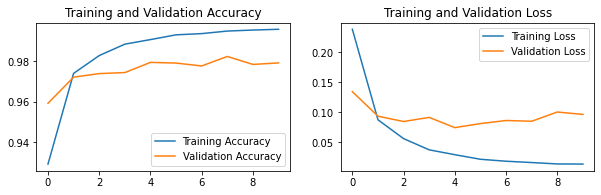

In [87]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

By visualizing the performance, we can check if the model is overfitting or underfitting the data. If the training accuracy is much higher than the validation accuracy, it means the model is overfitting, and if the validation accuracy is much higher than the training accuracy, it means the model is underfitting.

## C. Hyperparameter Tuning with GridSearchCV in Sklearn



we are going to use the same model in part a. but we will try to improve its performance with some hyperparamer tuning 

### c.1. loading the dataset from part a.

In [1]:
from sklearn import datasets

digits = datasets.load_digits()
X, y = digits.images, digits.target

X = X.reshape((X.shape[0], -1))
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### c.2. Import the GridSearchCV and MLPClassifier classes from the scikit-learn library.

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

### c.3. Define the hyperparameters and values to be searched over.
 The hyperparameters can include the activation function, solver, hidden layer sizes, number of hidden layers, regularization penalty and others. In this example, let's consider a few hyperparameters:

In [3]:
parameters = {
    'hidden_layer_sizes': [(50,50,50), (50,100,50), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['sgd', 'adam'],
}

### c.4. Create an instance of MLPClassifier, with default hyperparameters.

In [4]:
mlp = MLPClassifier(max_iter=1000, random_state=42)

### c.5 Create the GridSearchCV instance 
Create an instance of GridSearchCV and pass in the classifier, the hyperparameters to be searched, and the number of folds in the cross-validation (cv).


In [5]:
grid_search = GridSearchCV(mlp, parameters, cv=5)

### c.6. Train the classifier on the training data.

In [6]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000, random_state=42),
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50, 50, 50), (50, 100, 50),
                                                (100,)],
                         'solver': ['sgd', 'adam']})

In [10]:
print(grid_search.best_params_)

{'activation': 'relu', 'hidden_layer_sizes': (100,), 'solver': 'adam'}


The grid_search object now has the best parameters and the best classifier. You can access the best parameters with grid_search.best_params_ and the best classifier with grid_search.best_estimator_.

c.7. Evaluate the perfomance of the best classifier 

In [8]:
from sklearn.metrics import accuracy_score
y_pred = grid_search.best_estimator_.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(acc * 100))

Accuracy: 98.15%


Done. 